In [1]:
#task 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
print(df.head(10))


      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (545, 13)


In [5]:
target = "price"

features = df.drop(columns=[target])

print("Target Column:", target)
print("Feature Columns:")
print(features.columns.tolist())

Target Column: price
Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [6]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [7]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mea

In [8]:
#task 2
df = df.drop_duplicates()

In [9]:
df = df.fillna(df.mode().iloc[0])

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [11]:
df = pd.get_dummies(df,
                    columns=categorical_cols,
                    drop_first=True)

In [12]:
print(df.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

In [13]:
#task 3
X = df.drop("price", axis=1)
y = df["price"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
#model 1
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [17]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² :", r2_lr)

Linear Regression Results
MAE : 970043.403920164
RMSE: 1324506.9600914388
R² : 0.6529242642153184


In [18]:
#model 2
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [19]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² :", r2_rf)

Random Forest Results
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² : 0.611918531405699


In [20]:
#compare the model
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae_lr, mae_rf],
    "RMSE":[rmse_lr, rmse_rf],
    "R2 Score":[r2_lr, r2_rf]
})

print(comparison)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.021546e+06  1.400566e+06  0.611919


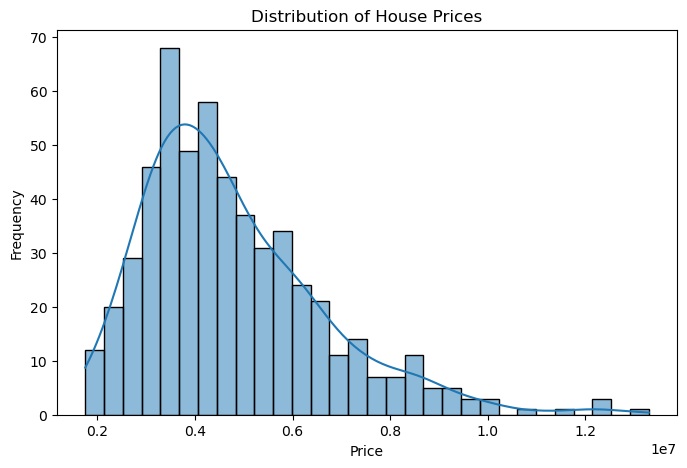

In [26]:
#task 4
plt.figure(figsize=(8,5))

sns.histplot(df["price"],
             bins=30,
             kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

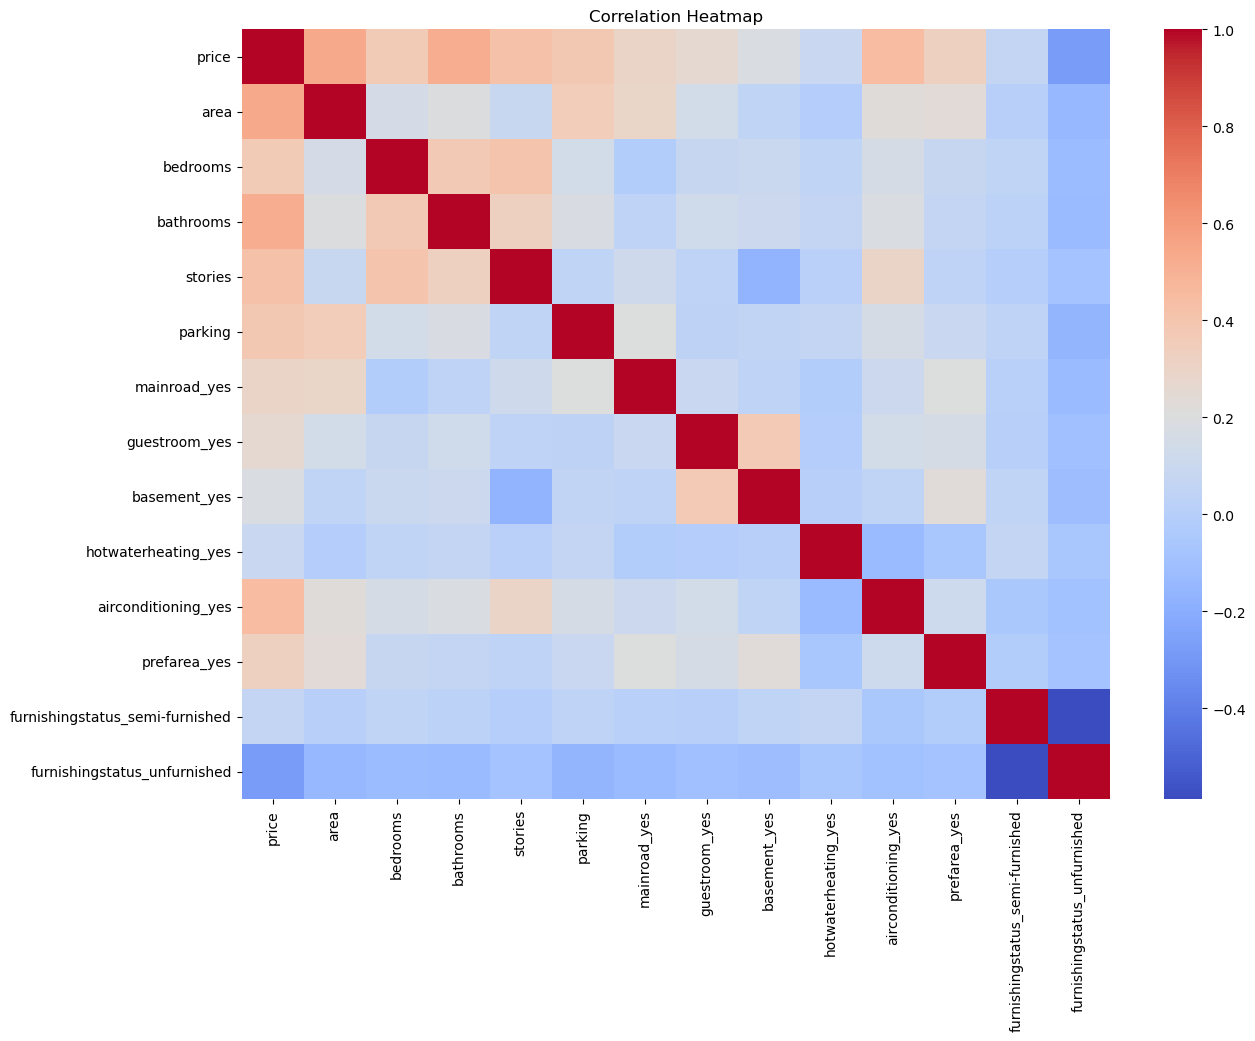

In [22]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

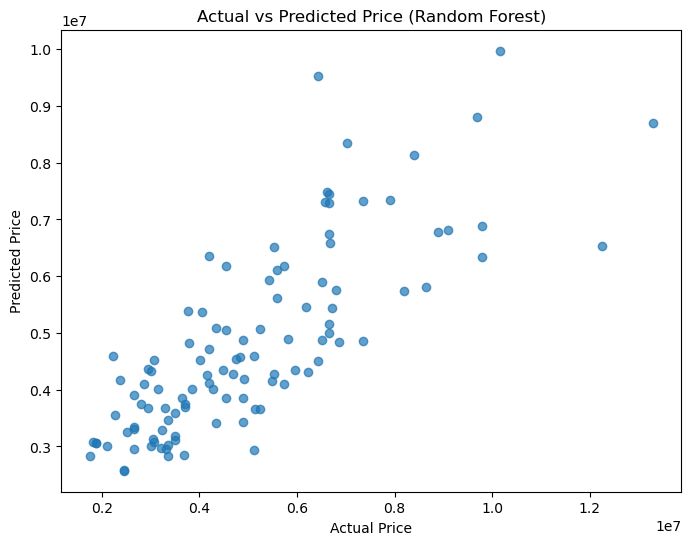

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.7
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price (Random Forest)")
plt.show()

In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                         Feature  Importance
0                           area    0.468430
2                      bathrooms    0.151483
9            airconditioning_yes    0.062672
4                        parking    0.057455
3                        stories    0.057133
1                       bedrooms    0.048413
12  furnishingstatus_unfurnished    0.035011
7                   basement_yes    0.030823
10                  prefarea_yes    0.030689
8            hotwaterheating_yes    0.017226


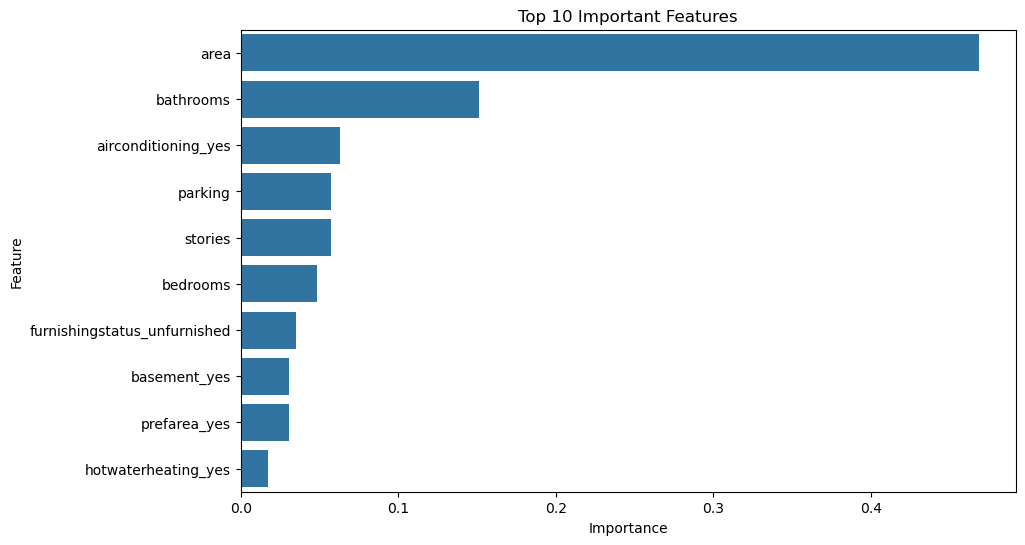

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
#task 5
#The analysis showed that area, number of bathrooms, air conditioning, and preferred location were among the strongest factors influencing house prices. 
#The Random Forest Regressor performed better than the Linear Regression model, achieving a higher R² score and lower error values. 
#This indicates that the relationship between house features and price is not entirely linear. 
#One interesting observation was that some amenities such as parking and furnishing status had a significant impact on price. 
#Based on these findings, real estate businesses should focus on highlighting property size, location, and key amenities when pricing or marketing houses.